# Visualization

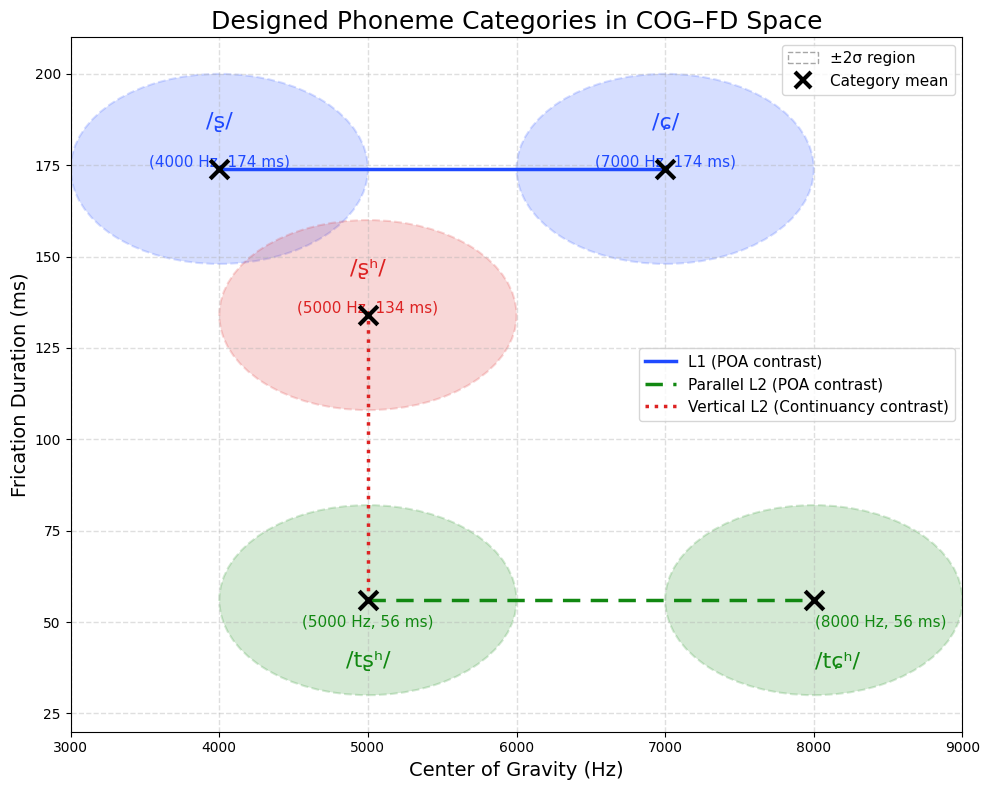

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

# ----------------------------
# Category means
# ----------------------------
points = {
    "ʂ":   {"x": 4000, "y": 174},
    "ɕ":   {"x": 7000, "y": 174},
    "tʂʰ": {"x": 5000, "y": 56},
    "tɕʰ": {"x": 8000, "y": 56},
    "ʂʰ":  {"x": 5000, "y": 134},
}

# ----------------------------
# Variability (1 SD)
# ----------------------------
cog_std = 500   # Hz
fd_std = 13     # ms

# ellipse size for ±2σ region
ellipse_width = 4 * cog_std   # total width = 4σ
ellipse_height = 4 * fd_std   # total height = 4σ

# ----------------------------
# Plot setup
# ----------------------------
fig, ax = plt.subplots(figsize=(10, 8))

ax.set_xlim(3000, 9000)
ax.set_ylim(20, 210)

ax.set_xlabel("Center of Gravity (Hz)", fontsize=14)
ax.set_ylabel("Frication Duration (ms)", fontsize=14)
ax.set_title("Designed Phoneme Categories in COG–FD Space", fontsize=18)

ax.grid(True, linestyle="--", linewidth=1, alpha=0.4)

# ----------------------------
# Colors
# ----------------------------
blue = "#1f4aff"
green = "#118811"
red = "#dd2222"

# ----------------------------
# Ellipses and mean markers
# ----------------------------
ellipse_specs = {
    "ʂ":   blue,
    "ɕ":   blue,
    "tʂʰ": green,
    "tɕʰ": green,
    "ʂʰ":  red,
}

for label, p in points.items():
    color = ellipse_specs[label]

    ell = Ellipse(
        (p["x"], p["y"]),
        width=ellipse_width,
        height=ellipse_height,
        facecolor=color,
        edgecolor=color,
        alpha=0.18,
        linewidth=1.5,
        linestyle="--"
    )
    ax.add_patch(ell)

    ax.scatter(
        p["x"], p["y"],
        marker="x",
        s=180,
        linewidths=3,
        color="black",
        zorder=5
    )

# ----------------------------
# Link lines for each contrast
# ----------------------------
# L1 pair
ax.plot(
    [points["ʂ"]["x"], points["ɕ"]["x"]],
    [points["ʂ"]["y"], points["ɕ"]["y"]],
    color=blue, linewidth=2.5, linestyle="-"
)

# Parallel pair
ax.plot(
    [points["tʂʰ"]["x"], points["tɕʰ"]["x"]],
    [points["tʂʰ"]["y"], points["tɕʰ"]["y"]],
    color=green, linewidth=2.5, linestyle=(0, (5, 3))
)

# Vertical pair
ax.plot(
    [points["tʂʰ"]["x"], points["ʂʰ"]["x"]],
    [points["tʂʰ"]["y"], points["ʂʰ"]["y"]],
    color=red, linewidth=2.5, linestyle=":"
)

# ----------------------------
# Labels
# ----------------------------
label_specs = {
    "ʂ":   {"color": blue,  "dx": 0,   "dy": 10, "ha": "center"},
    "ɕ":   {"color": blue,  "dx": 0,   "dy": 10, "ha": "center"},
    "tʂʰ": {"color": green, "dx": 0,   "dy": -14, "ha": "center"},
    "tɕʰ": {"color": green, "dx": 10,  "dy": -14, "ha": "left"},
    "ʂʰ":  {"color": red,   "dx": 0,   "dy": 10, "ha": "center"},
}

for label, p in points.items():
    spec = label_specs[label]
    ax.text(
        p["x"] + spec["dx"],
        p["y"] + spec["dy"],
        rf"/{label}/",
        color=spec["color"],
        fontsize=16,
        ha=spec["ha"],
        va="bottom" if spec["dy"] >= 0 else "top"
    )
    ax.text(
        p["x"] + spec["dx"],
        p["y"] + spec["dy"] - (6 if spec["dy"] >= 0 else -6),
        f'({p["x"]} Hz, {p["y"]} ms)',
        color=spec["color"],
        fontsize=11,
        ha=spec["ha"],
        va="top" if spec["dy"] >= 0 else "bottom"
    )

# ----------------------------
# Legends
# ----------------------------
contrast_handles = [
    Line2D([0], [0], color=blue, lw=2.5, linestyle="-", label="L1 (POA contrast)"),
    Line2D([0], [0], color=green, lw=2.5, linestyle=(0, (5, 3)), label="Parallel L2 (POA contrast)"),
    Line2D([0], [0], color=red, lw=2.5, linestyle=":", label="Vertical L2 (Continuancy contrast)"),
]

shape_handles = [
    Ellipse((0, 0), width=20, height=10, fill=False, edgecolor="gray", linestyle="--", alpha=0.7, label="±2σ region"),
    Line2D([0], [0], color="black", marker="x", linestyle="None", markersize=12, markeredgewidth=3, label="Category mean"),
]

legend1 = ax.legend(handles=contrast_handles, loc="center right", fontsize=11, frameon=True)
ax.add_artist(legend1)
ax.legend(handles=shape_handles, loc="upper right", fontsize=11, frameon=True)

plt.tight_layout()
plt.show()